<a href="https://colab.research.google.com/github/Keerthanatamma/nasscom/blob/main/Day_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path="powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists('powerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv('powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)



Generated dataset file.
train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


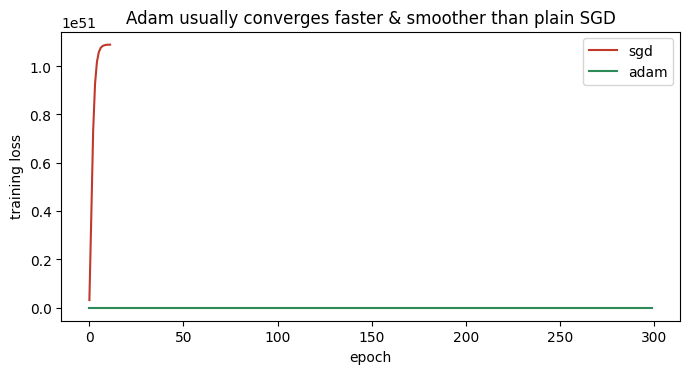

In [ ]:


# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()



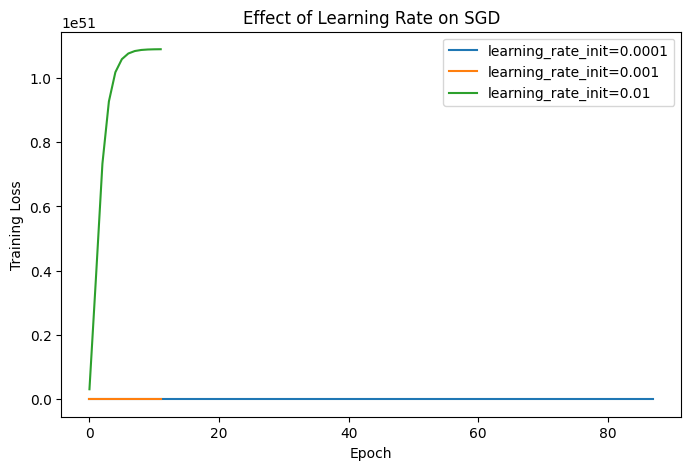

In [ ]:
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

# Three learning rates
lrs = [0.0001, 0.001, 0.01] # Reduced learning rates

plt.figure(figsize=(8,5))

for lr in lrs:
    nn = MLPRegressor(
        hidden_layer_sizes=(32,16),
        solver='sgd',
        learning_rate_init=lr,
        max_iter=300,
        random_state=0
    )

    nn.fit(Xtr, y_train)

    plt.plot(nn.loss_curve_, label=f'learning_rate_init={lr}')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Effect of Learning Rate on SGD')
plt.legend()
plt.show()

In [ ]:
# 1. best degree by test RMSE
best_degree = degrees[np.argmin(te_err)]

print("Best Degree:", best_degree)
print("Lowest Test RMSE:", min(te_err))

# 2. label the two ends:
# Low-degree end (Degree 1) -> High Bias / Underfitting
# High-degree end (Degree 7) -> High Variance / Overfitting

Best Degree: 2
Lowest Test RMSE: 3.7507351659252137


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# 1. Scale the degree-1 features (AT, V, AP, RH)
scaler = StandardScaler()

Xtr_scaled = scaler.fit_transform(X_train)
Xte_scaled = scaler.transform(X_test)

# Fit Lasso
lasso = Lasso(alpha=0.1)

lasso.fit(Xtr_scaled, y_train)

# 2. Print coefficients
features = ['AT', 'V', 'AP', 'RH']

for f, c in zip(features, lasso.coef_):
    print(f'{f}: {c:.4f}')

AT: -17.1994
V: -3.1238
AP: 0.2798
RH: 0.4102


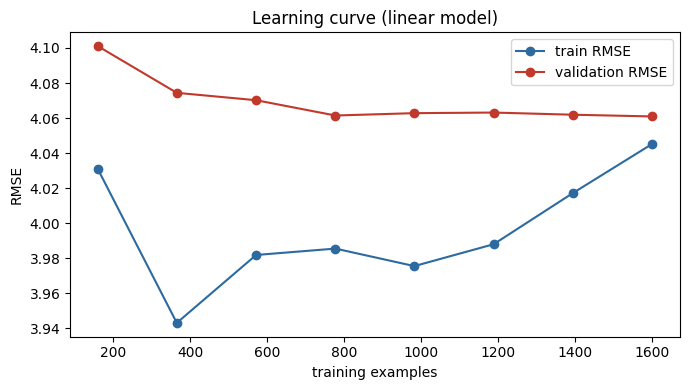

Both errors high and close => more bias-limited than variance-limited here.


In [ ]:


# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')



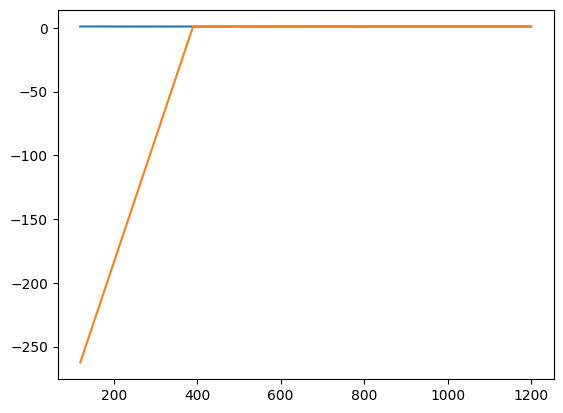

In [ ]:
model_d6 = make_pipeline(
    PolynomialFeatures(6),LinearRegression())

sizes, train_scores, val_scores = learning_curve(
    model_d6, X_train, y_train, cv=5
)

plt.plot(sizes, train_scores.mean(axis=1))
plt.plot(sizes, val_scores.mean(axis=1))
plt.show()

# Degree-6 -> High Variance (Overfitting)
# Larger train-validation gap than linear model.

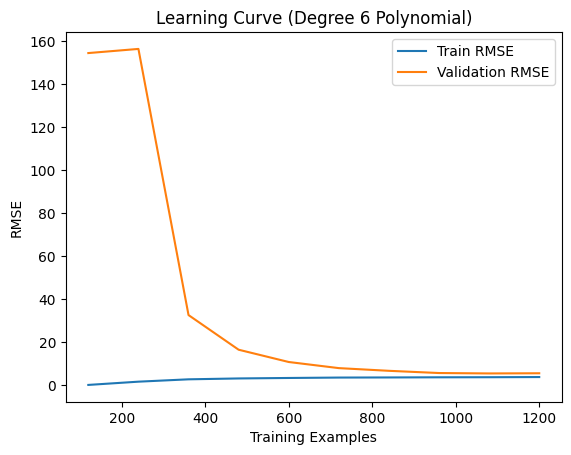

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# 1. learning curve for a degree-6 pipeline

pipe6 = make_pipeline(PolynomialFeatures(degree=6), StandardScaler(), LinearRegression())

sizes, train_scores, val_scores = learning_curve(
    pipe6,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.plot(sizes, train_rmse, label='Train RMSE')
plt.plot(sizes, val_rmse, label='Validation RMSE')
plt.xlabel("Training Examples")
plt.ylabel("RMSE")
plt.title("Learning Curve (Degree 6 Polynomial)")
plt.legend()
plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

best CV RMSE 4.05 at degree=3, alpha=10


In [ ]:
best_model = make_pipeline(
    PolynomialFeatures(best[1]),
    StandardScaler(),
    Ridge(alpha=best[2])
)
best_model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=10))])

In [ ]:


# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_concrete(csv_path="concrete_strength.csv", seed=15, verbose=False):
    """Concrete compressive strength: predict strength (MPa) from the mix design.
    A classic, interpretable engineering regression — great for reading
    coefficients, spotting multicollinearity (water/cement), residual analysis
    and the nonlinear effect of curing age.

    Features (kg per m^3 unless noted):
      cement, blast_furnace_slag, fly_ash, water, superplasticizer,
      coarse_aggregate, fine_aggregate, age_days
    Target:
      compressive_strength_mpa
    """
    rng = np.random.default_rng(seed)
    N = 1030
    cement = rng.uniform(120, 540, N)
    slag = np.where(rng.random(N) < 0.45, 0, rng.uniform(0, 360, N))
    fly_ash = np.where(rng.random(N) < 0.55, 0, rng.uniform(0, 200, N))
    water = np.clip(rng.normal(182, 21, N), 120, 247)
    superplast = np.clip(rng.normal(0.011 * cement + 0.5, 3.5, N), 0, 32)  # richer mixes use more
    coarse = rng.uniform(800, 1145, N)
    fine = np.clip(1880 - coarse + rng.normal(0, 35, N), 590, 995)        # aggregate volume ~ fixed -> trade-off
    age = rng.choice([1, 3, 7, 14, 28, 56, 90, 180, 365], N,
                     p=[.05, .10, .15, .10, .30, .12, .10, .05, .03])

    wc_ratio = water / cement
    strength = (24
                + 0.075 * cement
                + 0.052 * slag
                + 0.040 * fly_ash
                + 0.42 * superplast
                + 9.0 * np.log(age)
                - 0.18 * (water - 180)
                - 48 * (wc_ratio - 0.5)
                - 0.004 * (coarse - 970)
                + rng.normal(0, 5, N))
    strength = np.clip(strength, 2, 82)

    df = pd.DataFrame({
        "cement": cement.round(1),
        "blast_furnace_slag": slag.round(1),
        "fly_ash": fly_ash.round(1),
        "water": water.round(1),
        "superplasticizer": superplast.round(1),
        "coarse_aggregate": coarse.round(1),
        "fine_aggregate": fine.round(1),
        "age_days": age,
        "compressive_strength_mpa": strength.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("concrete:", df.shape)
        print("strength range:", df.compressive_strength_mpa.min(), "-", df.compressive_strength_mpa.max())
        c = df.corr()["compressive_strength_mpa"].round(3)
        print("top correlations with strength:\n",
              c.drop("compressive_strength_mpa").abs().sort_values(ascending=False).head(4).to_string())
        print("corr(water, cement):", round(df.water.corr(df.cement), 3))
    return df

if not os.path.exists('concrete_strength.csv'):
    build_concrete(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('concrete_strength.csv')
TARGET = 'compressive_strength_mpa'
print('shape:', df.shape)
df.describe().round(1)



Generated dataset file.
shape: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,compressive_strength_mpa
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,330.8,103.2,47.3,182.6,4.4,977.7,890.4,46.9,68.4
std,119.8,118.7,65.0,20.0,3.3,102.6,90.9,69.8,19.7
min,120.2,0.0,0.0,126.4,0.0,800.8,665.1,1.0,2.0
25%,225.3,0.0,0.0,168.2,1.7,887.5,812.6,7.0,59.9
50%,332.4,45.2,0.0,182.9,4.1,974.9,902.2,28.0,80.5
75%,431.2,204.7,97.0,196.1,6.6,1068.6,988.8,56.0,82.0
max,539.9,359.2,199.6,245.4,16.3,1144.9,995.0,365.0,82.0


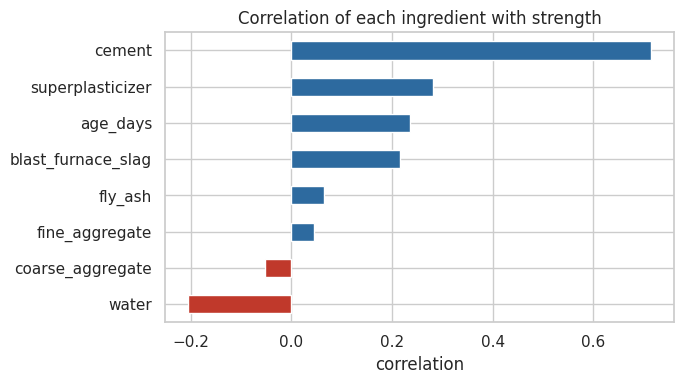

Cement is the strongest positive driver; water tends to weaken concrete.


In [ ]:

# -----------------------------------------------------------
# 🔹 1A. WHAT DRIVES STRENGTH?
# -----------------------------------------------------------
corr = df.corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in corr], ax=ax)
ax.set_title('Correlation of each ingredient with strength'); ax.set_xlabel('correlation')
plt.tight_layout(); plt.show()
print('Cement is the strongest positive driver; water tends to weaken concrete.')



strength = 0.117 * cement + 29.53


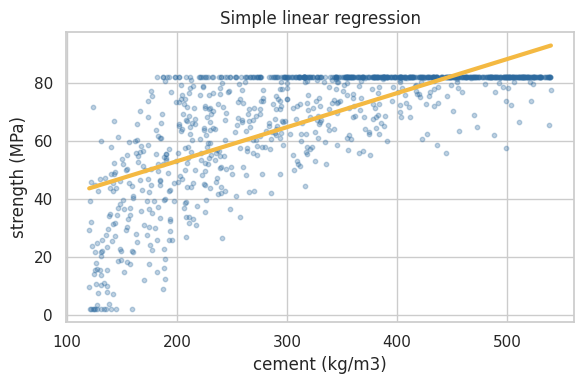

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. STRENGTH ~ CEMENT
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
x = df[['cement']].values
y = df[TARGET].values
slr = LinearRegression().fit(x, y)
print(f'strength = {slr.coef_[0]:.3f} * cement + {slr.intercept_:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50).reshape(-1, 1)
ax.plot(xs, slr.predict(xs), color='#F4B942', lw=3)
ax.set_xlabel('cement (kg/m3)'); ax.set_ylabel('strength (MPa)')
ax.set_title('Simple linear regression'); plt.tight_layout(); plt.show()

In [ ]:
pred_strength = slr.predict([[350]])
print("Predicted Strength:", pred_strength[0], "MPa")

Predicted Strength: 70.62987096305181 MPa


RMSE: 10.76 MPa | R2: 0.649


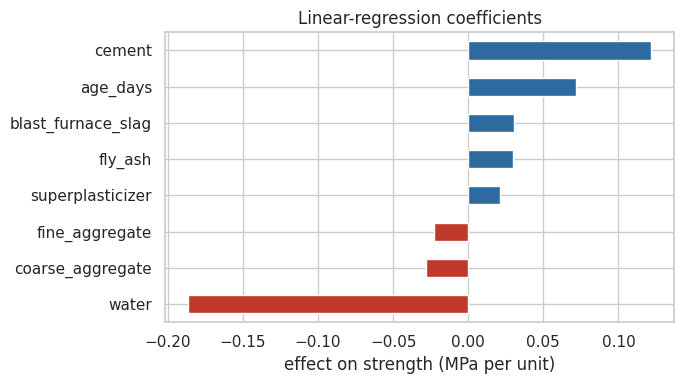

In [ ]:


# -----------------------------------------------------------
# 🔹 3A. FIT ON ALL INGREDIENTS, EVALUATE ON TEST
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
features = [c for c in df.columns if c != TARGET]
X = df[features].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
mlr = LinearRegression().fit(X_train, y_train)
pred = mlr.predict(X_test)
print(f'RMSE: {mean_squared_error(y_test, pred) ** 0.5:.2f} MPa | R2: {r2_score(y_test, pred):.3f}')


# Coefficients — the model's story about each ingredient
coefs = pd.Series(mlr.coef_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot(kind='barh', color=['#C0392B' if v < 0 else '#2D6A9F' for v in coefs], ax=ax)
ax.set_title('Linear-regression coefficients'); ax.set_xlabel('effect on strength (MPa per unit)')
plt.tight_layout(); plt.show()



In [ ]:
# Two ingredients with positive coefficients:
# Cement and Superplasticizer

# One ingredient with a negative coefficient:
# Water

# Yes, the negative sign on water matches engineering intuition.
# Adding more water generally reduces concrete strength because
# excess water increases the water-cement ratio and creates
# more pores/voids in the hardened concrete.
# Therefore, higher water content tends to weaken concrete.

In [ ]:
#feature selection
coefs = pd.Series(mlr.coef_, index=features).sort_values()
print(coefs)

water                -0.186295
coarse_aggregate     -0.027907
fine_aggregate       -0.023084
superplasticizer      0.020960
fly_ash               0.029525
blast_furnace_slag    0.030335
age_days              0.071570
cement                0.121586
dtype: float64


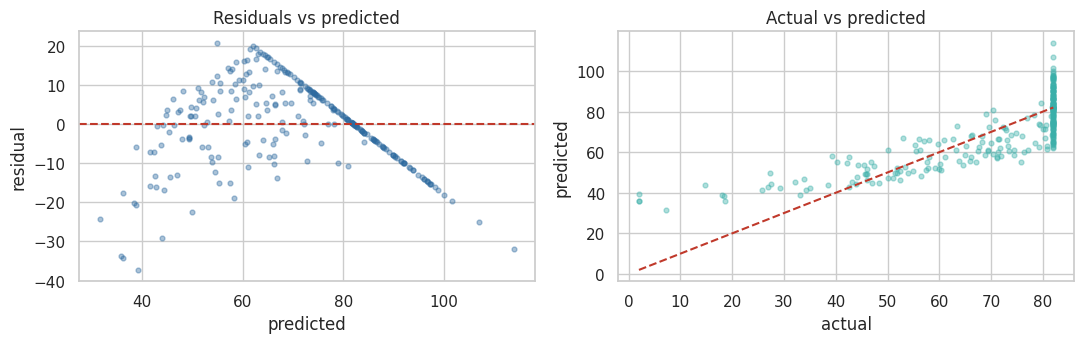

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. RESIDUALS vs PREDICTED — IS THE LINEAR FIT ADEQUATE?
# -----------------------------------------------------------
resid = y_test - pred
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=12, alpha=0.4, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].scatter(y_test, pred, s=12, alpha=0.4, color='#3AAFA9')
lims = [y_test.min(), y_test.max()]; ax[1].plot(lims, lims, color='#C0392B', ls='--')
ax[1].set_xlabel('actual'); ax[1].set_ylabel('predicted'); ax[1].set_title('Actual vs predicted')
plt.tight_layout(); plt.show()

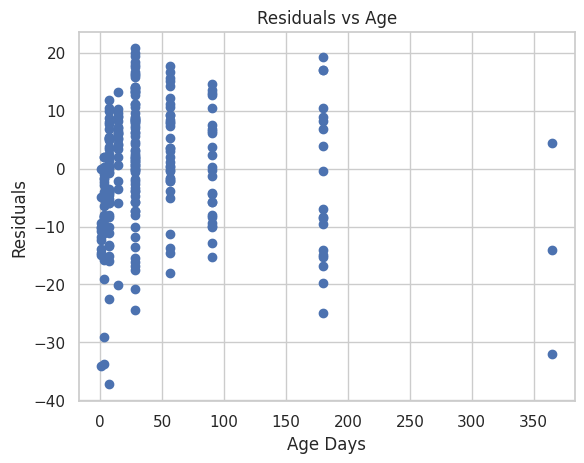

In [ ]:
# 1. residuals vs age_days
_, X_test_df, _, _ = train_test_split(df[features], y, test_size=0.25, random_state=42)
plt.scatter(X_test_df['age_days'], resid)
plt.xlabel("Age Days")
plt.ylabel("Residuals")
plt.title("Residuals vs Age")
plt.show()

# 2. pattern with age?
# A curved pattern may be visible.
# This suggests that age does not affect strength linearly.
# Concrete gains strength rapidly at early ages and then
# the increase slows down (plateaus) as age increases.

In [ ]:
r2=r2_score(y_test, pred)
print(f'R2: {r2:.3f}')

r2_log=r2_score(np.log(y_test), np.log(pred))
print(f'R2 (log): {r2_log:.3f}')

#bonus: degree-2 polynomial features + R2
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
mlr_poly = LinearRegression().fit(X_train_poly, y_train)
pred_poly = mlr_poly.predict(X_test_poly)
r2_poly = r2_score(y_test, pred_poly)
print(f'R2 (degree-2 polynomial): {r2_poly:.3f}')


R2: 0.649
R2 (log): 0.451
R2 (degree-2 polynomial): 0.858


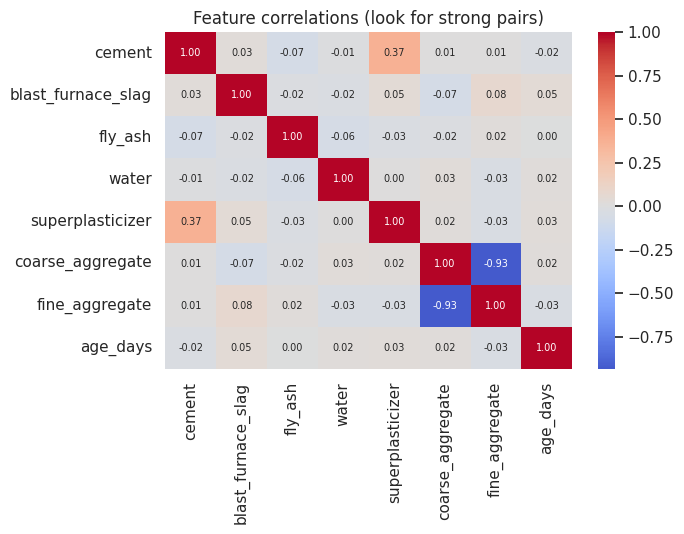

coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).
Linear       test R2: 0.649
Ridge(10)    test R2: 0.650
Lasso(0.5)   test R2: 0.648


In [ ]:


# -----------------------------------------------------------
# 🔹 6A. SPOT CORRELATED FEATURES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature correlations (look for strong pairs)'); plt.tight_layout(); plt.show()
print('coarse_aggregate and fine_aggregate trade off -> strongly correlated (multicollinearity).')


# -----------------------------------------------------------
# 🔹 6B. RIDGE STABILISES CORRELATED-FEATURE WEIGHTS
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
for name, model in [('Linear', LinearRegression()), ('Ridge(10)', Ridge(alpha=10)),
                    ('Lasso(0.5)', Lasso(alpha=0.5, max_iter=5000))]:
    m = make_pipeline(StandardScaler(), model).fit(X_train, y_train)
    r2 = r2_score(y_test, m.predict(X_test))
    print(f'{name:12s} test R2: {r2:.3f}')



In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
import pandas as pd # Import pandas for Series if not already imported in this cell

# 1. Compare coarse/fine coefficients: Linear vs Ridge

# Linear Regression Model
linear_model_pipeline = make_pipeline(StandardScaler(), LinearRegression())
linear_model_pipeline.fit(X_train, y_train)
# Access coefficients from the LinearRegression step in the pipeline
linear_coefs = linear_model_pipeline.named_steps['linearregression'].coef_
print("Linear Regression Coefficients:")
for i, feature in enumerate(features):
    print(f"  {feature}: {linear_coefs[i]:.4f}")

# Ridge Regression Model (using alpha=10 as in previous cell's example)
ridge_model_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge_model_pipeline.fit(X_train, y_train)
# Access coefficients from the Ridge step in the pipeline
ridge_coefs = ridge_model_pipeline.named_steps['ridge'].coef_
print("\nRidge(10) Regression Coefficients:")
for i, feature in enumerate(features):
    print(f"  {feature}: {ridge_coefs[i]:.4f}")

# 2. Did Ridge stabilise them? (comment)
# By comparing the coefficients, especially for 'coarse_aggregate' and 'fine_aggregate',
# we can observe if Ridge regression has stabilized their values (made them smaller and less extreme)
# due to its L2 regularization, which helps in cases of multicollinearity.

Linear Regression Coefficients:
  cement: 14.4859
  blast_furnace_slag: 3.5681
  fly_ash: 1.8964
  water: -3.6887
  superplasticizer: 0.0700
  coarse_aggregate: -2.8485
  fine_aggregate: -2.0857
  age_days: 5.2341

Ridge(10) Regression Coefficients:
  cement: 14.2647
  blast_furnace_slag: 3.5304
  fly_ash: 1.8642
  water: -3.6505
  superplasticizer: 0.1592
  coarse_aggregate: -2.4502
  fine_aggregate: -1.6843
  age_days: 5.1657


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge

# Linear Regression
lr = make_pipeline(StandardScaler(), LinearRegression())
lr.fit(X_train, y_train)

# Ridge Regression
ridge = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge.fit(X_train, y_train)

# coarse_aggregate = index 5
# fine_aggregate   = index 6

print("Linear:")
print("Coarse =", lr.named_steps['linearregression'].coef_[5])
print("Fine   =", lr.named_steps['linearregression'].coef_[6])

print("\nRidge:")
print("Coarse =", ridge.named_steps['ridge'].coef_[5])
print("Fine   =", ridge.named_steps['ridge'].coef_[6])

# Ridge shrank the coarse_aggregate and fine_aggregate coefficients.
# The weights become smaller and more stable due to L2 regularization.
# Therefore, Ridge helps reduce the effects of multicollinearity.

Linear:
Coarse = -2.848495053210748
Fine   = -2.08570726998042

Ridge:
Coarse = -2.4501831412672774
Fine   = -1.6842659136522464


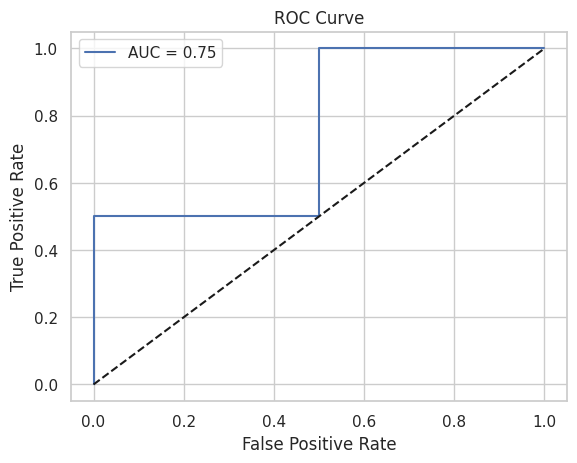

In [ ]:


#import neccessarily libraries
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
%matplotlib inline

y_true = [0, 0, 1, 1]
y_scores = [0.1, 0.4, 0.35, 0.8]  # probability scores

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

#visualize the ROC-AUC

# Plot the ROC curve: True Positive Rate (TPR) vs False Positive Rate (FPR)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")  # ROC curve with AUC value in legend

# Plot a diagonal reference line (classifier with no skill)
plt.plot([0, 1], [0, 1], 'k--')  # 'k--' means black dashed line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


